In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from utils import plot_tsne
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 128
batch_size = 128
num_epochs_ae = 30
num_epochs_cls = 30
learning_rate = 1e-3
# Early stopping parameters
patience = 4
best_val_loss = float('inf')
patience_counter = 0
checkpoint_dir = 'checkpoints'
patience_classifier = 4
best_val_loss_classifier = float('inf')
patience_counter_classifier = 0
os.makedirs(checkpoint_dir, exist_ok=True)

# Configuration
config = {
    'MNIST': {
        'input_channels': 1,
        'input_size': 28,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'mean': (0.1307,),
        'std': (0.3081,)
    },
    'CIFAR10': {
        'input_channels': 3,
        'input_size': 32,
        'num_classes': 10,
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        'mean': (0.4914, 0.4822, 0.4465),
        'std': (0.2470, 0.2435, 0.2616)
    }
}

In [ ]:

# class Autoencoder(nn.Module): # Gal
#     def __init__(self, input_channels, input_size):
#         super().__init__()
#         self.input_dim = input_channels * input_size ** 2
#         self.input_channels = input_channels
#         self.input_size = input_size
#         self.encoder = nn.Sequential(
#             nn.Linear(self.input_dim, 512),
#             nn.ReLU(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Linear(256, latent_dim)
#         )
#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, 256),
#             nn.ReLU(),
#             nn.Linear(256, 512),
#             nn.ReLU(),
#             nn.Linear(512, self.input_dim)
#         )

#     def forward(self, x):
#         x = x.view(-1, self.input_dim)
#         x = self.encoder(x)
#         x = self.decoder(x)
#         return x.view(-1, self.input_channels, self.input_size, self.input_size)   

latent_dim = 128  # Define globally for consistency

class Autoencoder(nn.Module):
    def __init__(self, input_channels, input_size):
        super().__init__()
        self.input_dim = input_channels * input_size ** 2
        self.input_channels = input_channels
        self.input_size = input_size
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, self.input_dim)
        )

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, self.input_channels, self.input_size, self.input_size)




In [ ]:
# class Classifier(nn.Module): # Gal
#     def __init__(self, encoder, input_dim, num_classes, latent_dim=128):
#         super().__init__()
#         self.encoder = encoder
#         self.input_dim = input_dim
#         self.fc1 = nn.Linear(latent_dim, 1024)
#         self.bn1 = nn.BatchNorm1d(1024)
#         self.fc2 = nn.Linear(1024, 1024)
#         self.bn2 = nn.BatchNorm1d(1024)
#         self.fc3 = nn.Linear(1024, num_classes)
#         self.dropout = nn.Dropout(0.321)  # Dropout with 50% probability

#     def forward(self, x):
#         x = x.view(-1, self.input_dim)
#         x = self.encoder(x)
#         x = F.relu(self.bn1(self.fc1(x)))
#         x = self.dropout(x)
#         x = F.relu(self.bn2(self.fc2(x)))
#         x = self.dropout(x)
#         x = self.fc3(x)
#         return x
class Classifier(nn.Module):
    def __init__(self, encoder, input_dim, num_classes, latent_dim=128):
        super().__init__()
        self.encoder = encoder
        self.input_dim = input_dim
        self.fc1 = nn.Linear(latent_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        x = self.encoder(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.fc2(x)
        return x

In [4]:
def load_dataset(dataset_name):
    cfg = config[dataset_name]
    if dataset_name == 'MNIST':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=cfg['transform'])
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=cfg['transform'])
    elif dataset_name == 'CIFAR10':
        train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cfg['transform'])
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cfg['transform'])
    
    # Split train into train and validation
    train_size = len(train_dataset) - 10000
    train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])
    
    return train_dataset, val_dataset, test_dataset

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )



In [12]:
def train_autoencoder(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 6  # Increased
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in tqdm(train_loader, desc=f"AE Epoch {epoch+1}"):
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        val_loss = evaluate(model, val_loader, device, criterion)
        print(f'AE Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}')
        scheduler.step(val_loss)  # Adjust learning rate

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/ae_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
        if isinstance(model, Autoencoder):
            with torch.no_grad():
                dataiter = iter(val_loader)
                images, _ = next(dataiter)
                images = images.to(device)
                outputs = model(images)
                images = images.cpu()
                outputs = outputs.cpu()
                
                # Get image dimensions automatically
                batch_size, channels, height, width = images.shape
                random_indices = torch.randperm(batch_size)[:5]

                # Denormalize images using the config values
                def denormalize(x, dataset_name):
                    mean = torch.tensor(config[dataset_name]['mean']).view(channels, 1, 1)
                    std = torch.tensor(config[dataset_name]['std']).view(channels, 1, 1)
                    return x * std + mean
                
                images_display = denormalize(images, dataset_name)
                outputs_display = denormalize(outputs, dataset_name)
                
                fig, axes = plt.subplots(2, 5, figsize=(12, 4))
                for i in range(5):
                    idx = random_indices[i]
                    if channels == 1:
                        axes[0, i].imshow(images_display[idx].squeeze(), cmap='gray')
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].squeeze(), cmap='gray')
                        axes[1, i].axis('off')
                    else:
                        axes[0, i].imshow(images_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[0, i].axis('off')
                        axes[1, i].imshow(outputs_display[idx].permute(1, 2, 0).clamp(0, 1))
                        axes[1, i].axis('off')
                
                axes[0, 0].set_title('Original', size=14)
                axes[1, 0].set_title('Reconstructed', size=14)
                plt.tight_layout()
                plt.show()
    return model

def train_classifier(model, train_loader, val_loader, device, num_epochs, dataset_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    best_val_acc = 0
    patience_counter = 0
    patience = 6  # Increased
    checkpoint_dir = f'checkpoints/{dataset_name}'
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"CLS Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        val_acc = evaluate_classifier(model, val_loader, device)
        print(f'CLS Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f}, Val Acc: {val_acc:.2f}%')
        scheduler.step(val_acc)  # Adjust learning rate based on accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'{checkpoint_dir}/cls_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    return model

def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, images).item()
    return total_loss / len(loader)

def evaluate_classifier(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


In [28]:
dataset_name = "MNIST"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


Training Autoencoder on MNIST


AE Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

AE Epoch 1: 100%|██████████| 391/391 [00:15<00:00, 24.69it/s]


AE Epoch [1/15] Train Loss: 0.3135, Val Loss: 0.1698


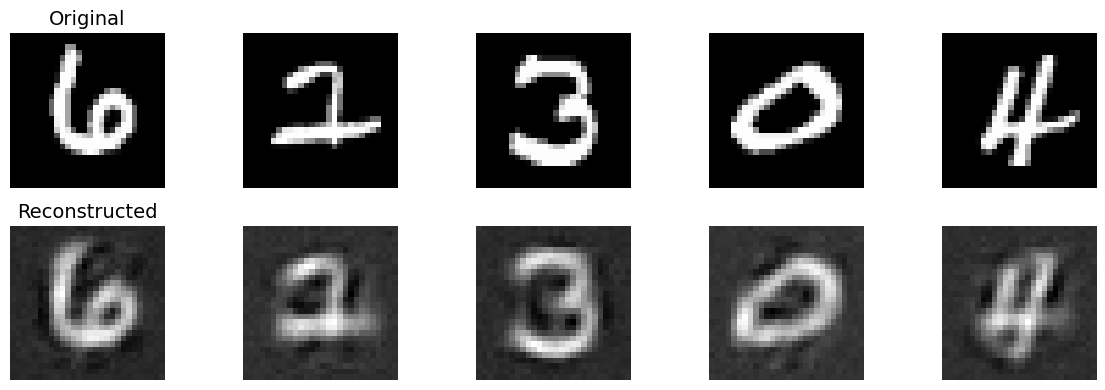

AE Epoch 2: 100%|██████████| 391/391 [00:15<00:00, 25.84it/s]


AE Epoch [2/15] Train Loss: 0.1403, Val Loss: 0.1185


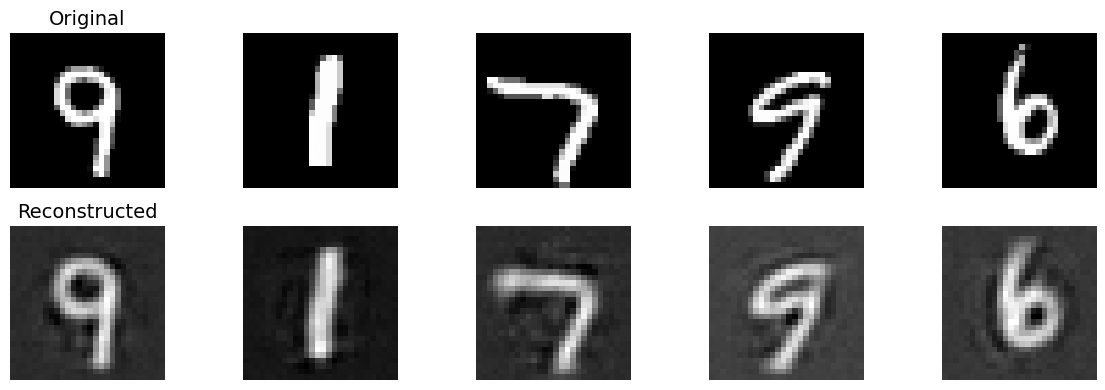

AE Epoch 3: 100%|██████████| 391/391 [00:13<00:00, 29.97it/s]


AE Epoch [3/15] Train Loss: 0.1079, Val Loss: 0.0983


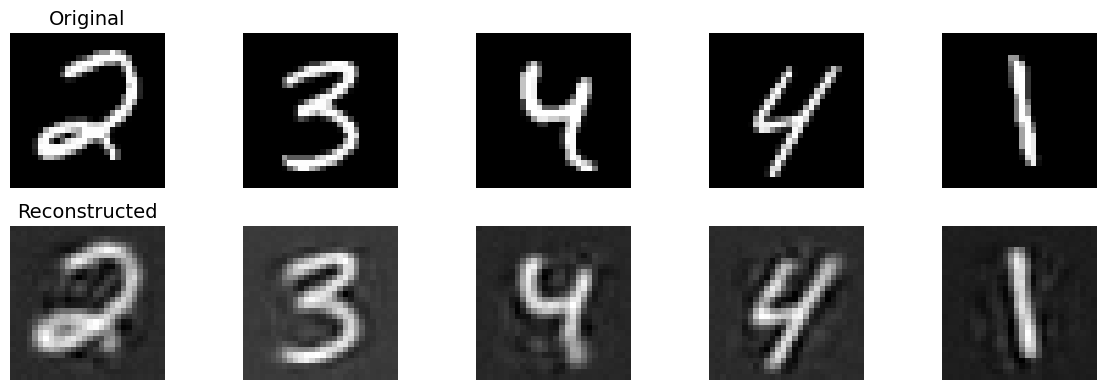

AE Epoch 4: 100%|██████████| 391/391 [00:13<00:00, 29.78it/s]


AE Epoch [4/15] Train Loss: 0.0922, Val Loss: 0.0873


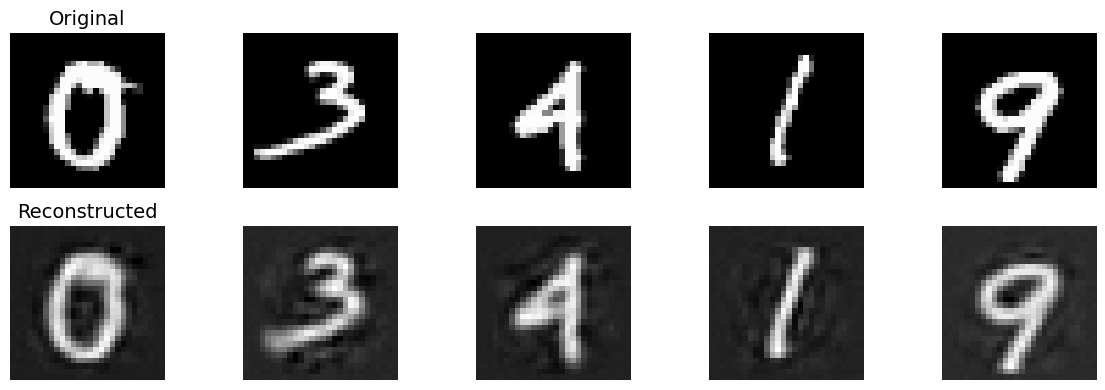

AE Epoch 5: 100%|██████████| 391/391 [00:13<00:00, 29.28it/s]


AE Epoch [5/15] Train Loss: 0.0821, Val Loss: 0.0784


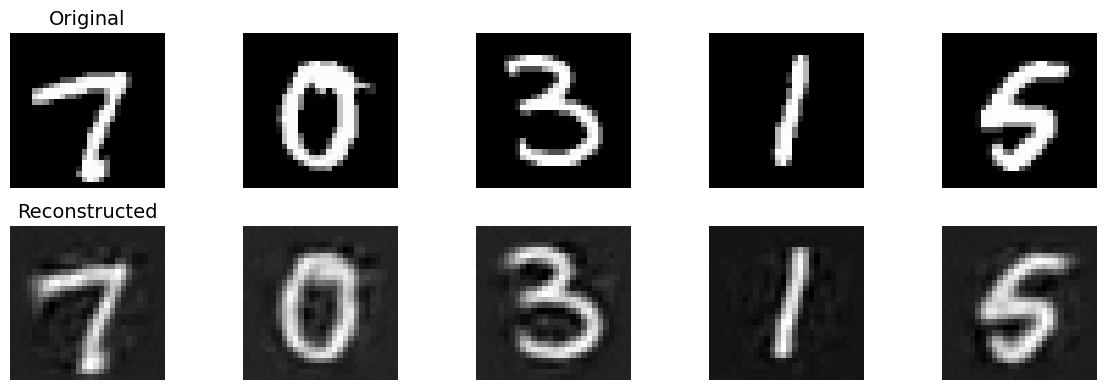

AE Epoch 6: 100%|██████████| 391/391 [00:12<00:00, 30.68it/s]


AE Epoch [6/15] Train Loss: 0.0749, Val Loss: 0.0732


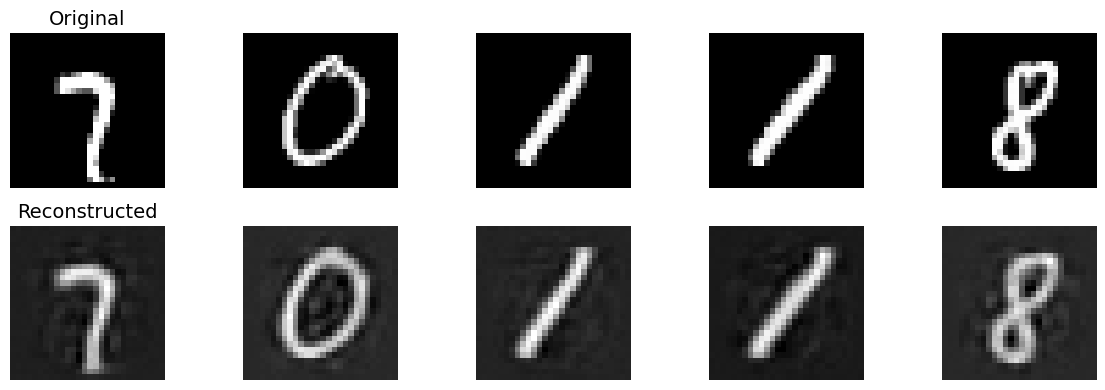

AE Epoch 7: 100%|██████████| 391/391 [00:13<00:00, 29.92it/s]


AE Epoch [7/15] Train Loss: 0.0696, Val Loss: 0.0678


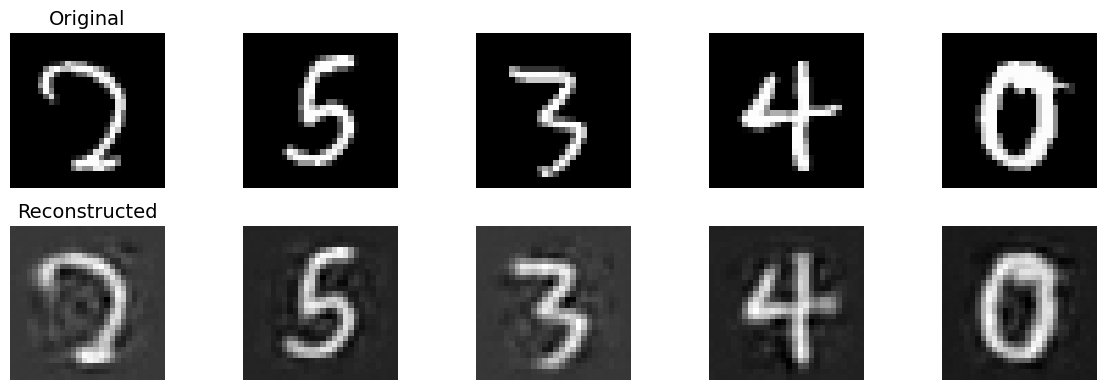

AE Epoch 8: 100%|██████████| 391/391 [00:12<00:00, 30.96it/s]


AE Epoch [8/15] Train Loss: 0.0654, Val Loss: 0.0641


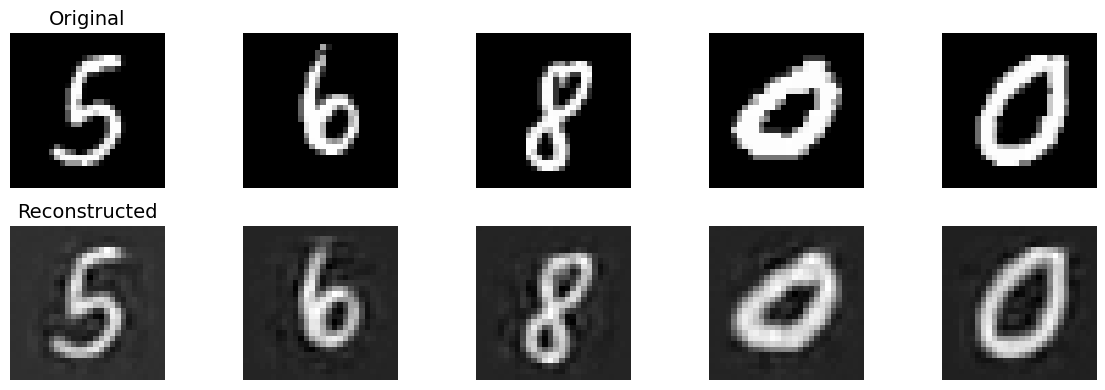

AE Epoch 9: 100%|██████████| 391/391 [00:12<00:00, 30.59it/s]


AE Epoch [9/15] Train Loss: 0.0619, Val Loss: 0.0617


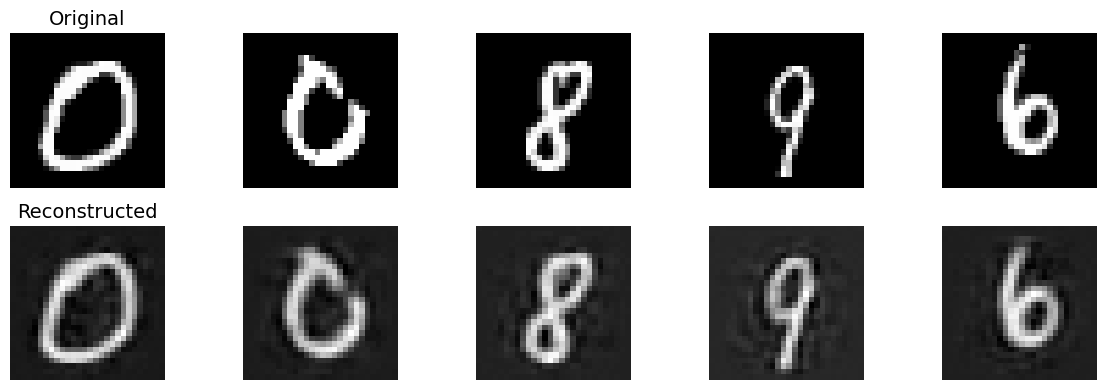

AE Epoch 10: 100%|██████████| 391/391 [00:12<00:00, 30.14it/s]


AE Epoch [10/15] Train Loss: 0.0592, Val Loss: 0.0585


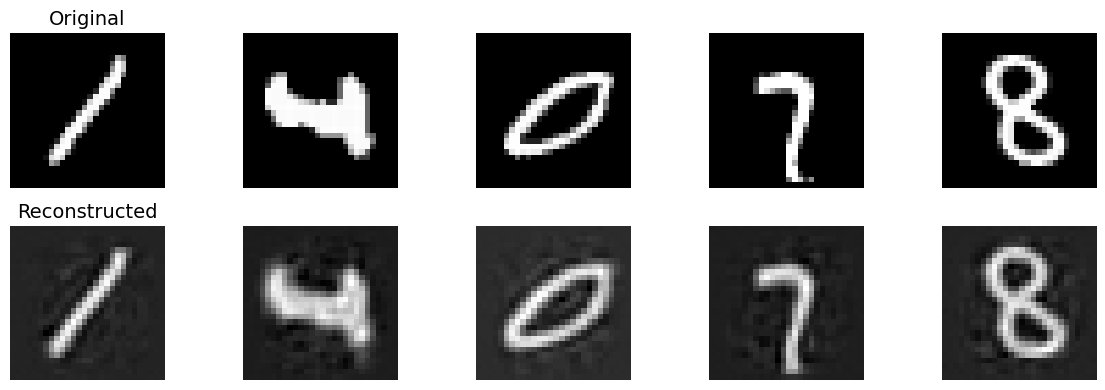

AE Epoch 11: 100%|██████████| 391/391 [00:13<00:00, 29.18it/s]


AE Epoch [11/15] Train Loss: 0.0567, Val Loss: 0.0552


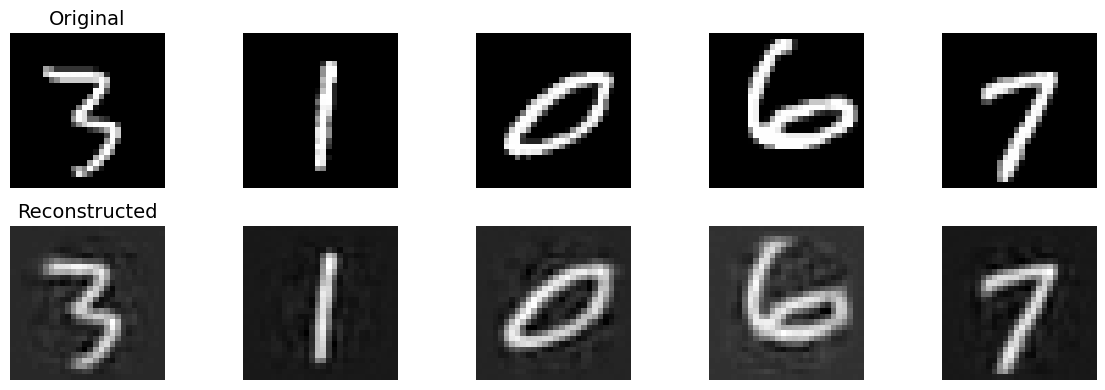

AE Epoch 12: 100%|██████████| 391/391 [00:15<00:00, 25.77it/s]


AE Epoch [12/15] Train Loss: 0.0547, Val Loss: 0.0544


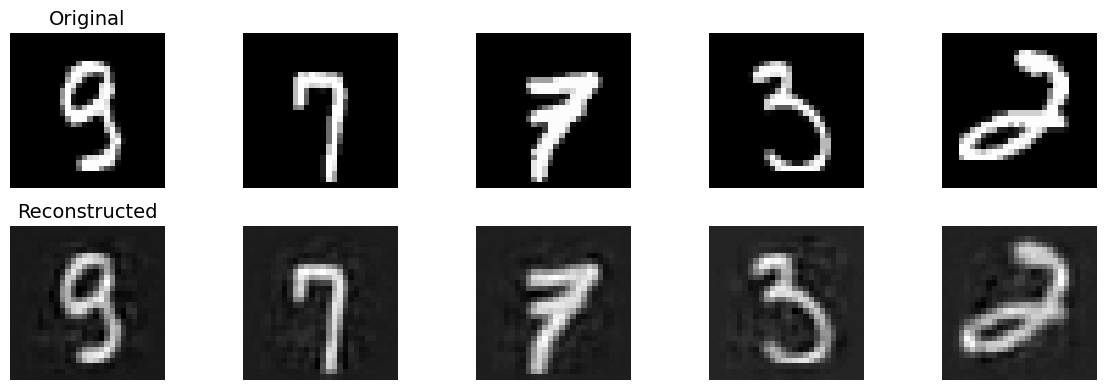

AE Epoch 13: 100%|██████████| 391/391 [00:13<00:00, 28.13it/s]


AE Epoch [13/15] Train Loss: 0.0530, Val Loss: 0.0576


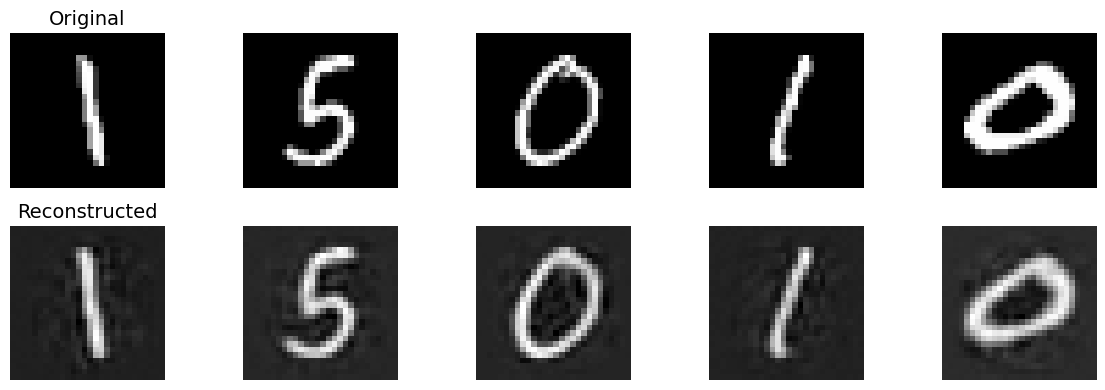

AE Epoch 14: 100%|██████████| 391/391 [00:13<00:00, 28.76it/s]


AE Epoch [14/15] Train Loss: 0.0514, Val Loss: 0.0520


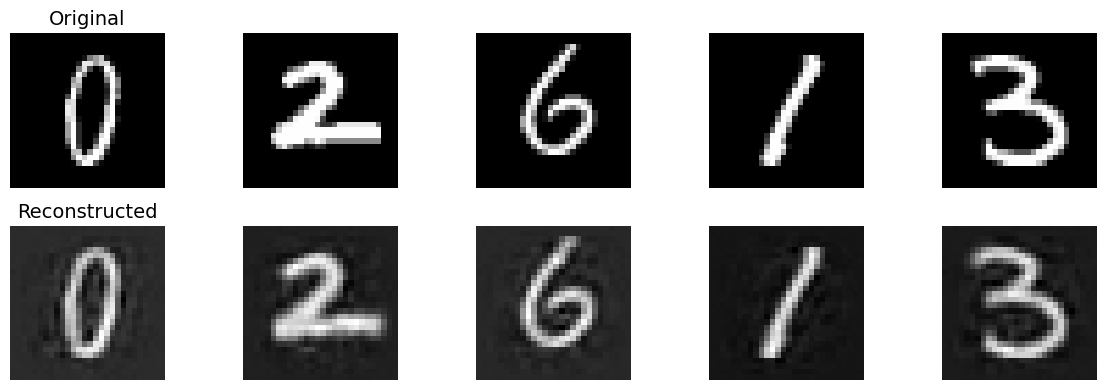

AE Epoch 15: 100%|██████████| 391/391 [00:13<00:00, 29.04it/s]


AE Epoch [15/15] Train Loss: 0.0501, Val Loss: 0.0498


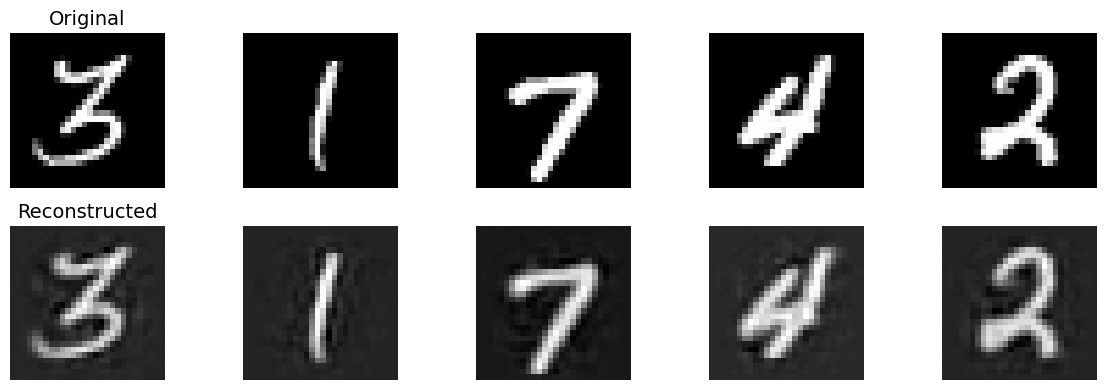

In [29]:
ae = Autoencoder(cfg['input_channels'], cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, num_epochs_ae, dataset_name)





In [30]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0489


In [32]:
# Classifier

classifier = Classifier(ae.encoder, ae.input_dim, cfg['num_classes']).to(device)
# classifier = Classifier(ae.encoder, config[dataset_name]['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, num_epochs_cls, dataset_name)


Training Classifier on MNIST


CLS Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

CLS Epoch 1: 100%|██████████| 391/391 [00:13<00:00, 29.88it/s]


CLS Epoch [1/15] Train Loss: 0.2711, Val Acc: 96.49%


CLS Epoch 2: 100%|██████████| 391/391 [00:13<00:00, 29.67it/s]


...

CLS Epoch [13/15] Train Loss: 0.0546, Val Acc: 98.29%


CLS Epoch 14: 100%|██████████| 391/391 [00:12<00:00, 31.13it/s]


CLS Epoch [14/15] Train Loss: 0.0538, Val Acc: 98.39%


CLS Epoch 15: 100%|██████████| 391/391 [00:12<00:00, 30.71it/s]


CLS Epoch [15/15] Train Loss: 0.0487, Val Acc: 98.51%


In [33]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')




Final Test Accuracy on MNIST: 98.51%


In [34]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne


In [35]:

# Visualization
plot_tsne(ae.encoder, test_loader, device)


KeyboardInterrupt: 

In [ ]:
####################################

In [7]:
# now for CIFAR10
dataset_name = "CIFAR10"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)


In [8]:
print(device)

cuda


Training Autoencoder on CIFAR10


AE Epoch 1: 100%|██████████| 313/313 [00:07<00:00, 40.89it/s]


AE Epoch [1/30] Train Loss: 0.0560, Val Loss: 0.0348


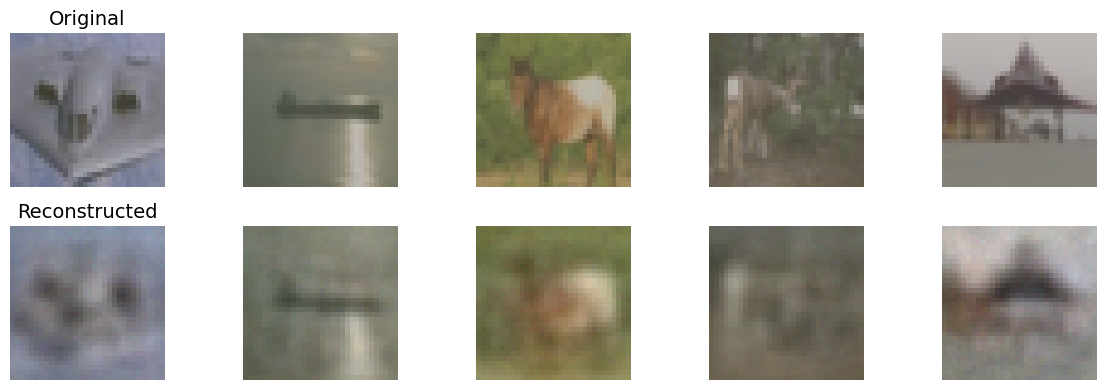

AE Epoch 2: 100%|██████████| 313/313 [00:08<00:00, 36.51it/s]


AE Epoch [2/30] Train Loss: 0.0300, Val Loss: 0.0279


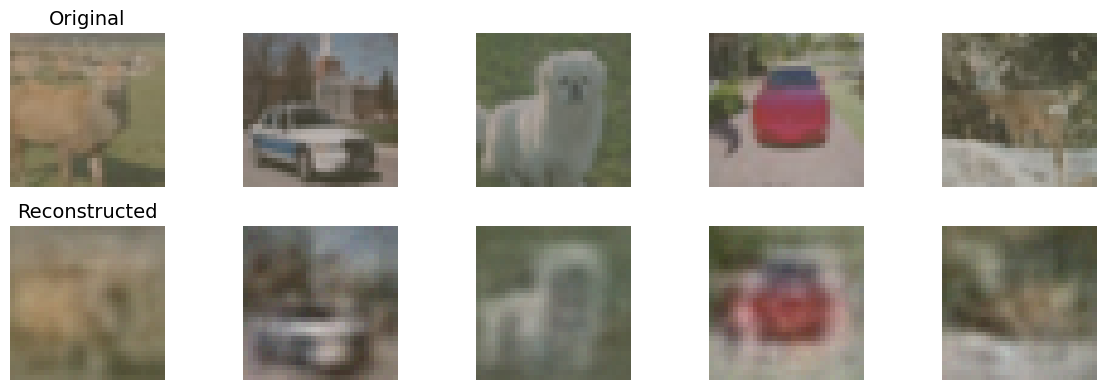

AE Epoch 3: 100%|██████████| 313/313 [00:08<00:00, 36.13it/s]


AE Epoch [3/30] Train Loss: 0.0263, Val Loss: 0.0266


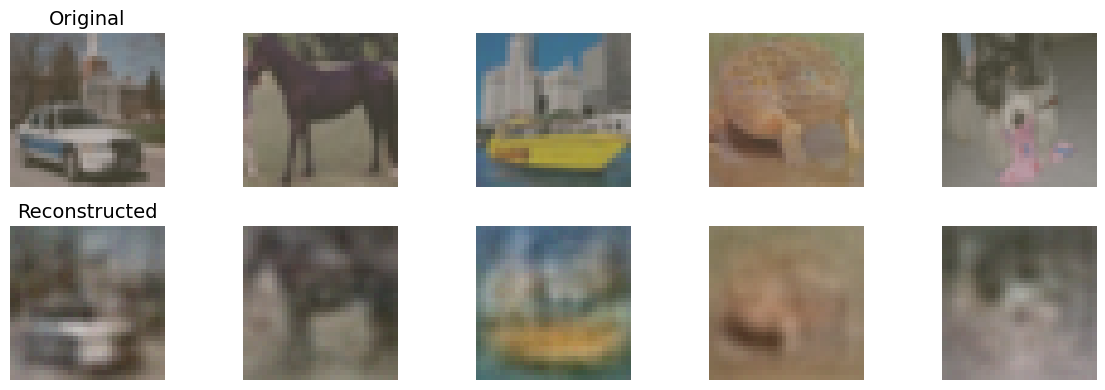

AE Epoch 4: 100%|██████████| 313/313 [00:08<00:00, 36.62it/s]


AE Epoch [4/30] Train Loss: 0.0252, Val Loss: 0.0253


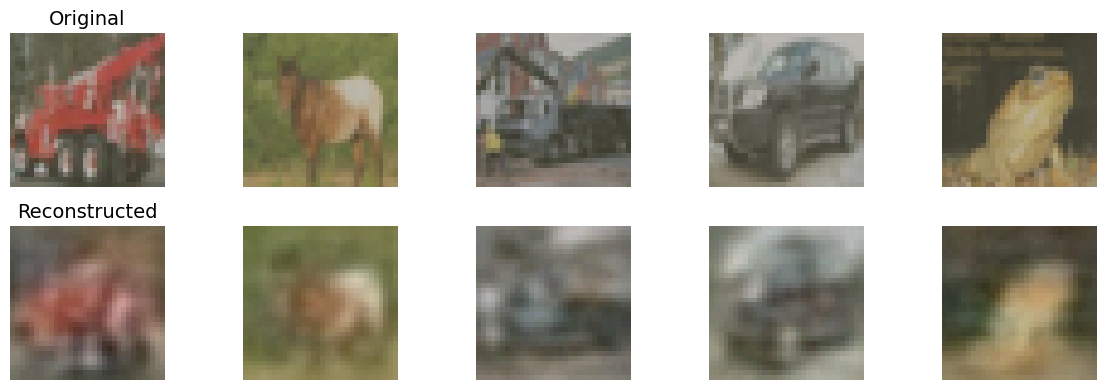

AE Epoch 5: 100%|██████████| 313/313 [00:08<00:00, 36.57it/s]


AE Epoch [5/30] Train Loss: 0.0246, Val Loss: 0.0248


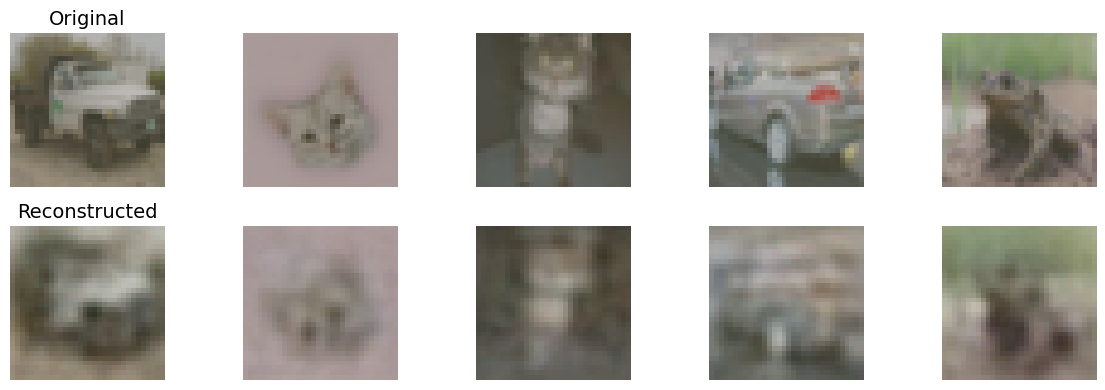

AE Epoch 6: 100%|██████████| 313/313 [00:08<00:00, 36.82it/s]


AE Epoch [6/30] Train Loss: 0.0241, Val Loss: 0.0243


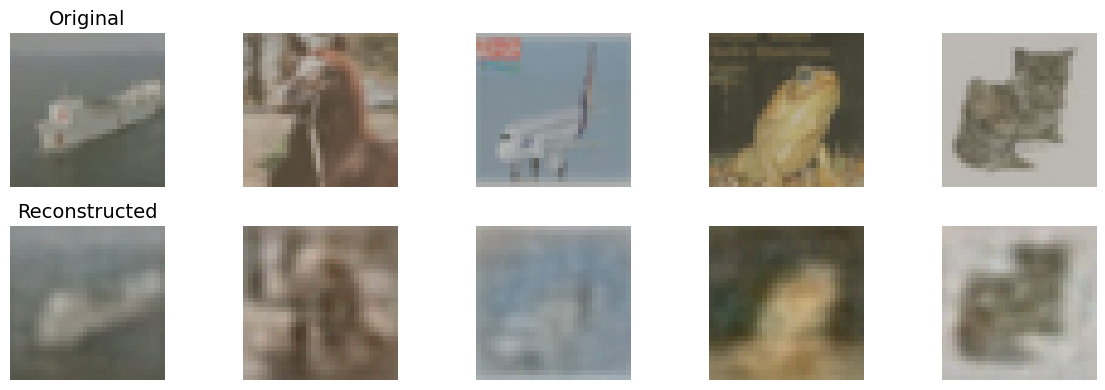

AE Epoch 7: 100%|██████████| 313/313 [00:08<00:00, 37.26it/s]


AE Epoch [7/30] Train Loss: 0.0238, Val Loss: 0.0242


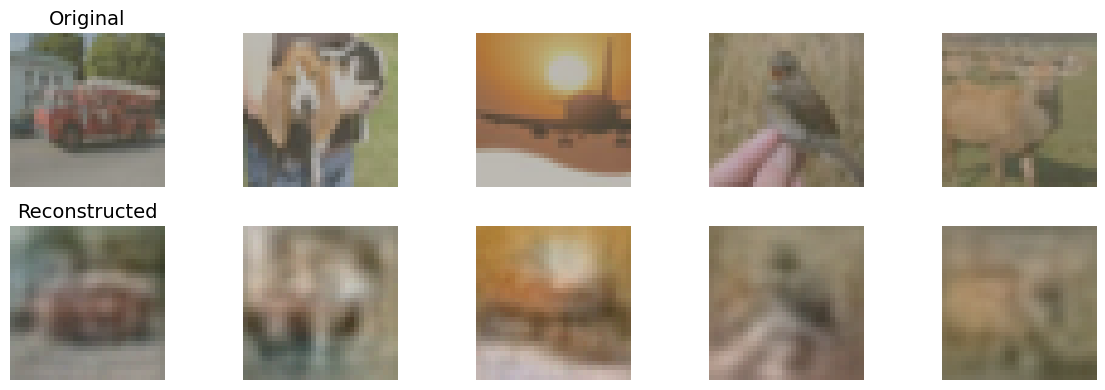

AE Epoch 8: 100%|██████████| 313/313 [00:08<00:00, 36.73it/s]


AE Epoch [8/30] Train Loss: 0.0233, Val Loss: 0.0240


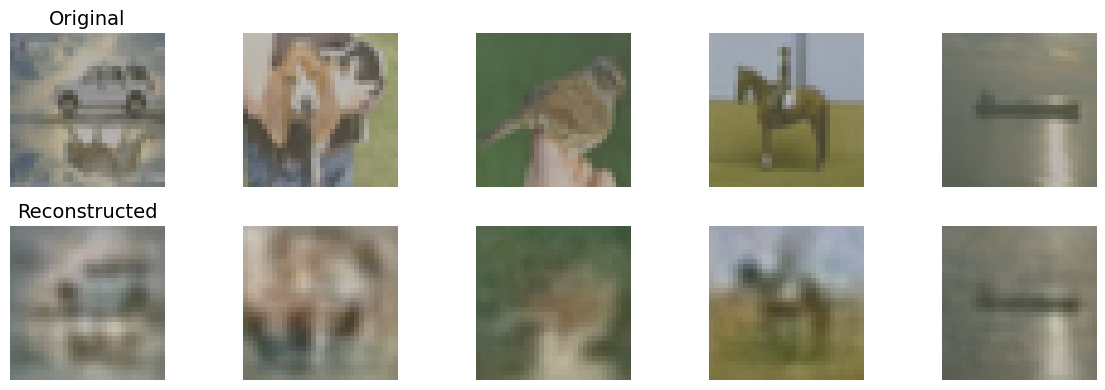

AE Epoch 9: 100%|██████████| 313/313 [00:08<00:00, 37.37it/s]


AE Epoch [9/30] Train Loss: 0.0232, Val Loss: 0.0239


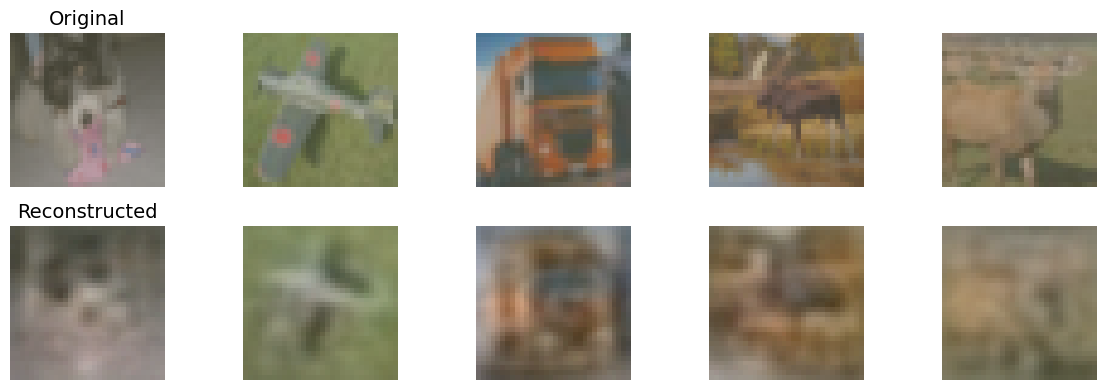

AE Epoch 10: 100%|██████████| 313/313 [00:08<00:00, 36.26it/s]


AE Epoch [10/30] Train Loss: 0.0230, Val Loss: 0.0237


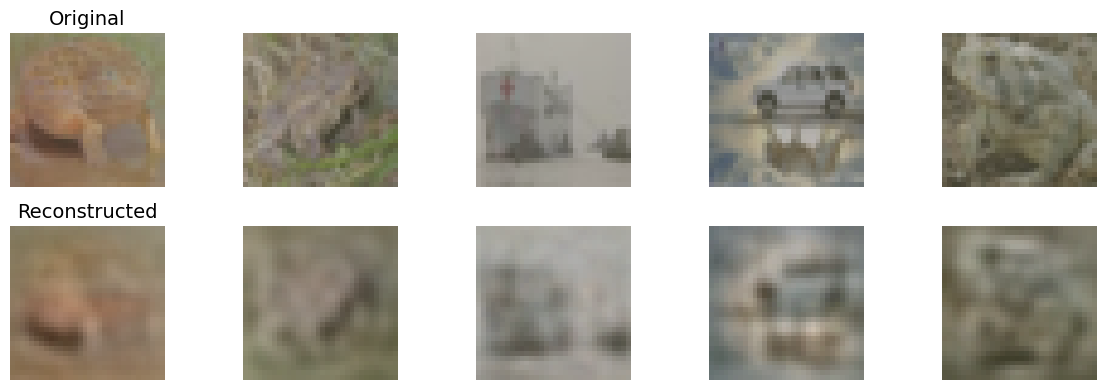

AE Epoch 11: 100%|██████████| 313/313 [00:08<00:00, 36.31it/s]


AE Epoch [11/30] Train Loss: 0.0228, Val Loss: 0.0238


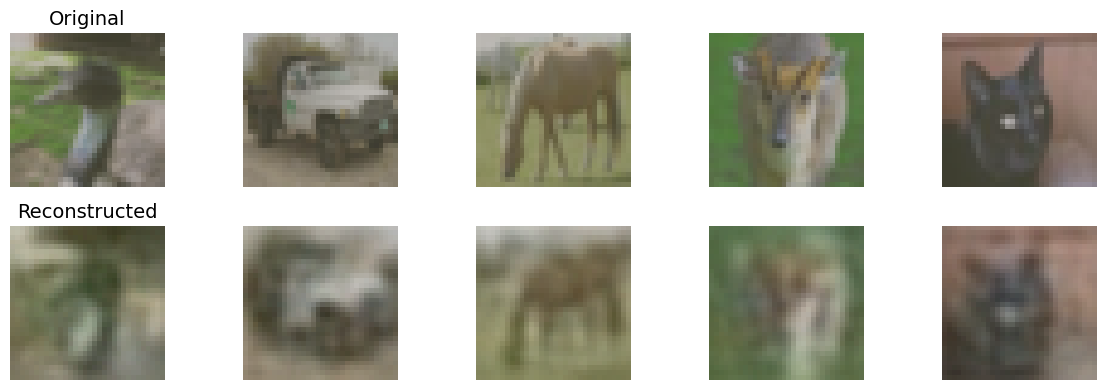

AE Epoch 12: 100%|██████████| 313/313 [00:08<00:00, 36.94it/s]


AE Epoch [12/30] Train Loss: 0.0228, Val Loss: 0.0234


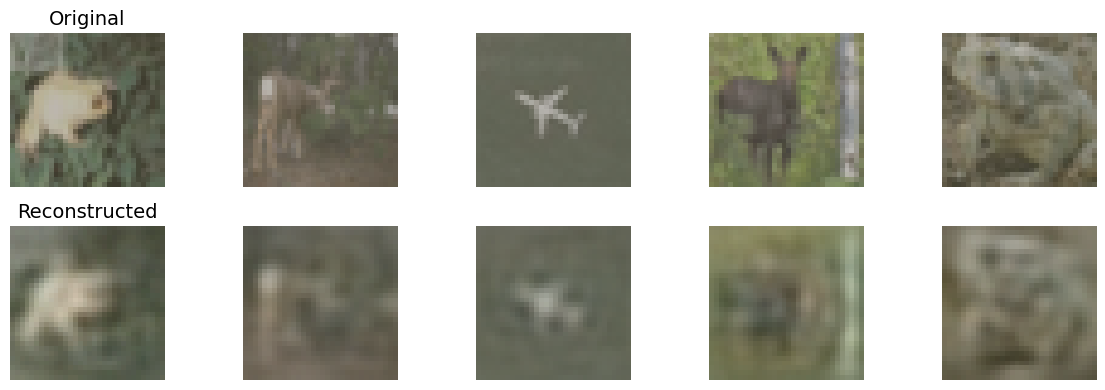

AE Epoch 13: 100%|██████████| 313/313 [00:08<00:00, 37.23it/s]


AE Epoch [13/30] Train Loss: 0.0226, Val Loss: 0.0233


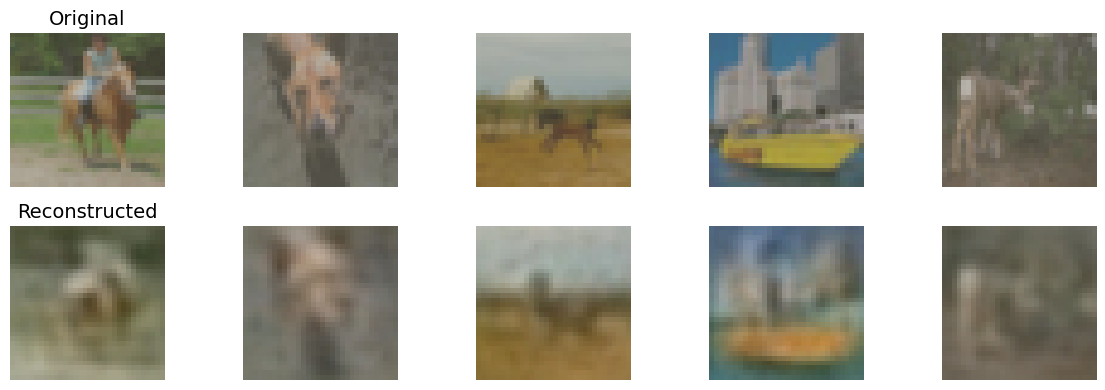

AE Epoch 14: 100%|██████████| 313/313 [00:09<00:00, 34.62it/s]


AE Epoch [14/30] Train Loss: 0.0226, Val Loss: 0.0235


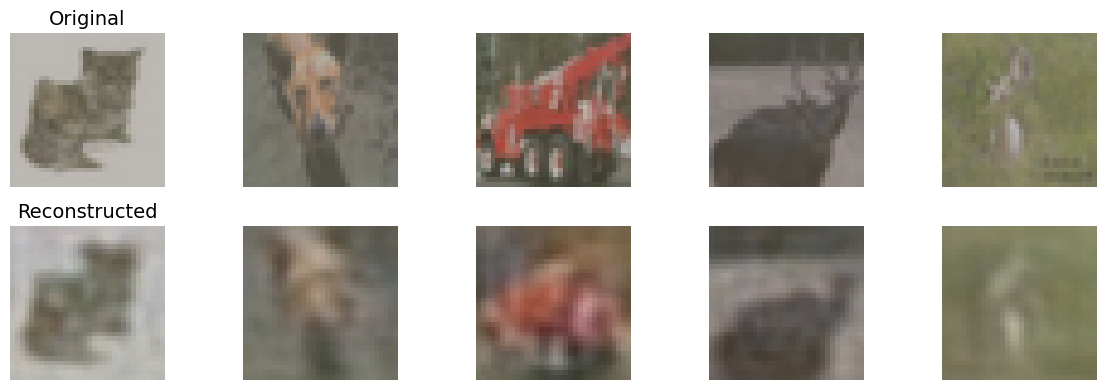

AE Epoch 15: 100%|██████████| 313/313 [00:09<00:00, 34.61it/s]


AE Epoch [15/30] Train Loss: 0.0226, Val Loss: 0.0236


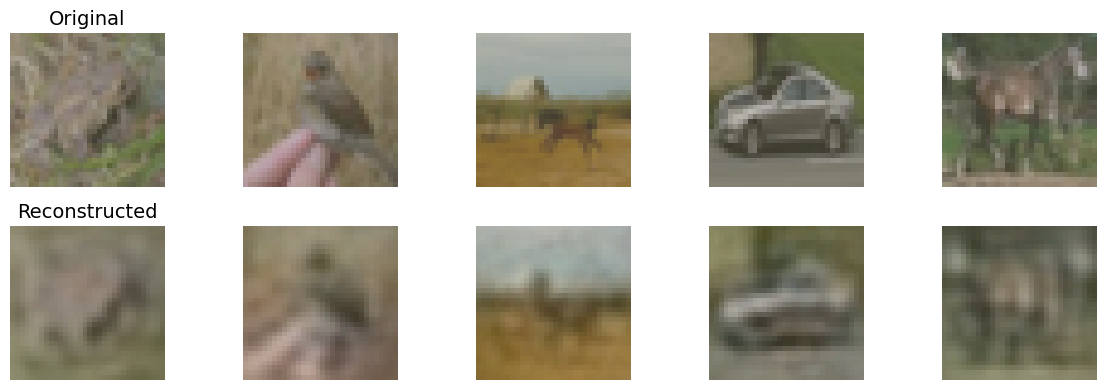

AE Epoch 16: 100%|██████████| 313/313 [00:08<00:00, 35.05it/s]


AE Epoch [16/30] Train Loss: 0.0225, Val Loss: 0.0234


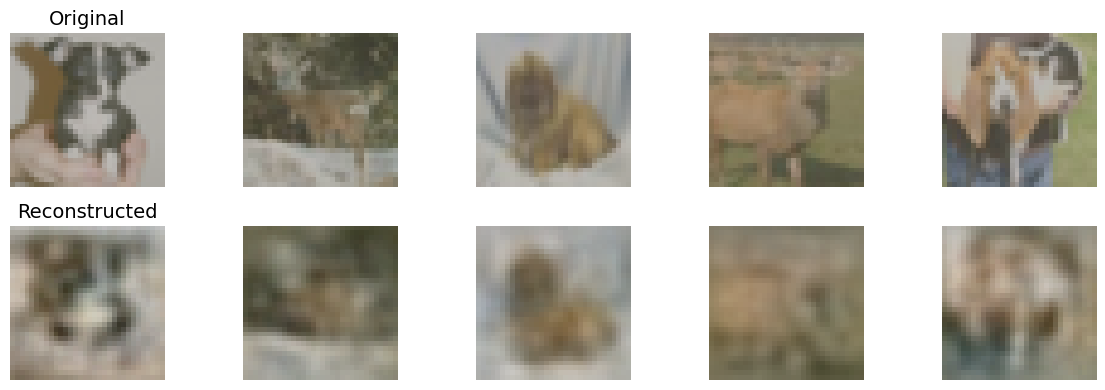

AE Epoch 17: 100%|██████████| 313/313 [00:09<00:00, 34.42it/s]


AE Epoch [17/30] Train Loss: 0.0223, Val Loss: 0.0233


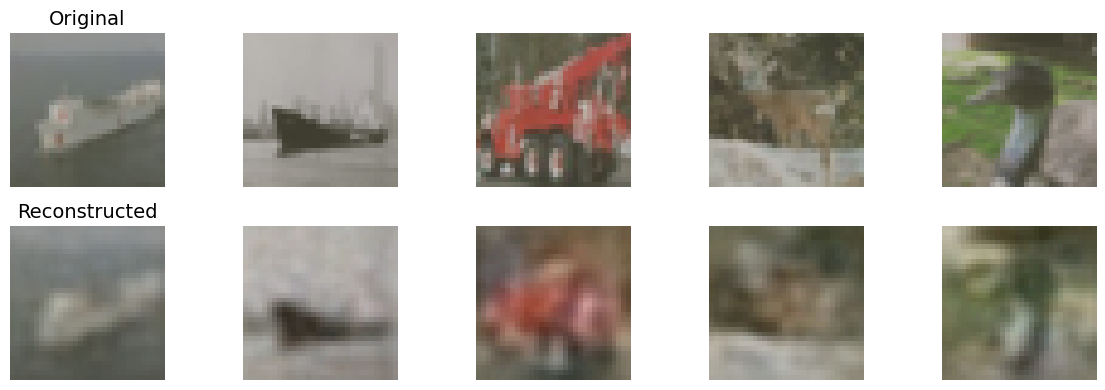

AE Epoch 18: 100%|██████████| 313/313 [00:09<00:00, 34.26it/s]


AE Epoch [18/30] Train Loss: 0.0224, Val Loss: 0.0233


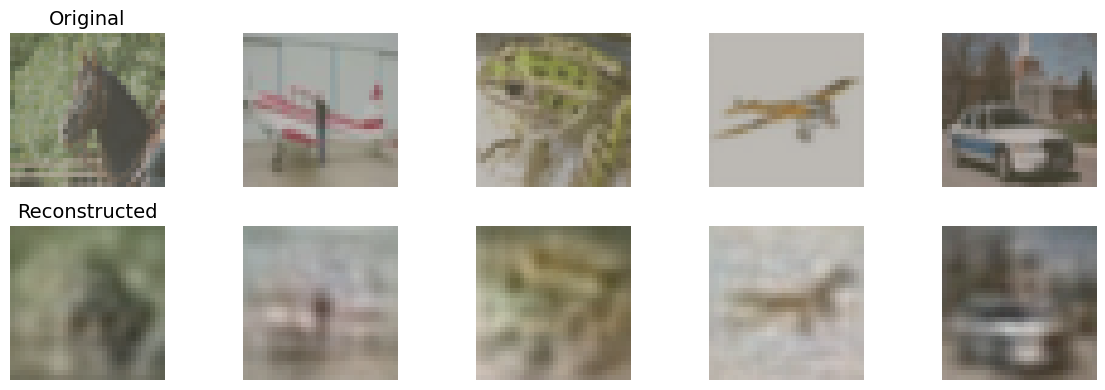

AE Epoch 19: 100%|██████████| 313/313 [00:08<00:00, 35.64it/s]


AE Epoch [19/30] Train Loss: 0.0223, Val Loss: 0.0233


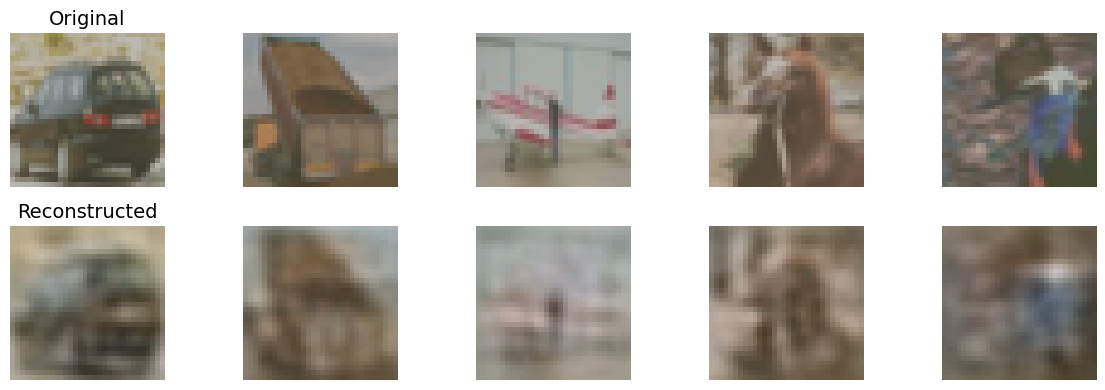

AE Epoch 20: 100%|██████████| 313/313 [00:08<00:00, 36.44it/s]


AE Epoch [20/30] Train Loss: 0.0222, Val Loss: 0.0231


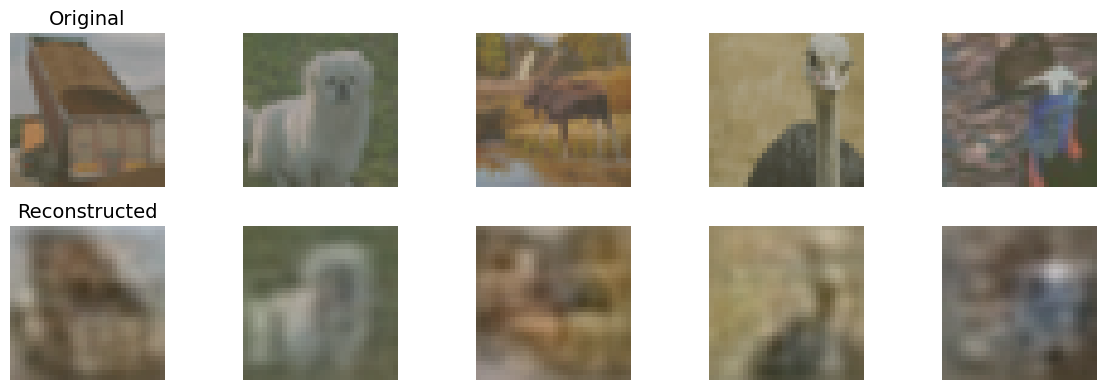

AE Epoch 21: 100%|██████████| 313/313 [00:08<00:00, 36.19it/s]


AE Epoch [21/30] Train Loss: 0.0221, Val Loss: 0.0232


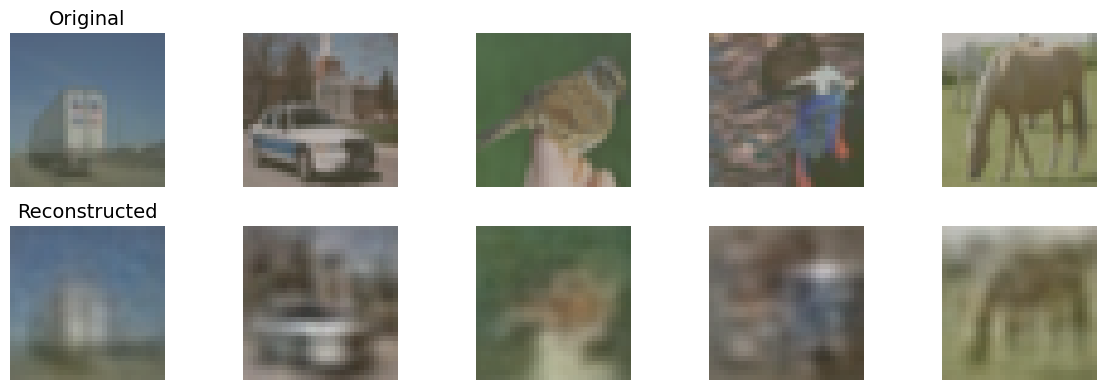

AE Epoch 22: 100%|██████████| 313/313 [00:08<00:00, 36.23it/s]


AE Epoch [22/30] Train Loss: 0.0221, Val Loss: 0.0232


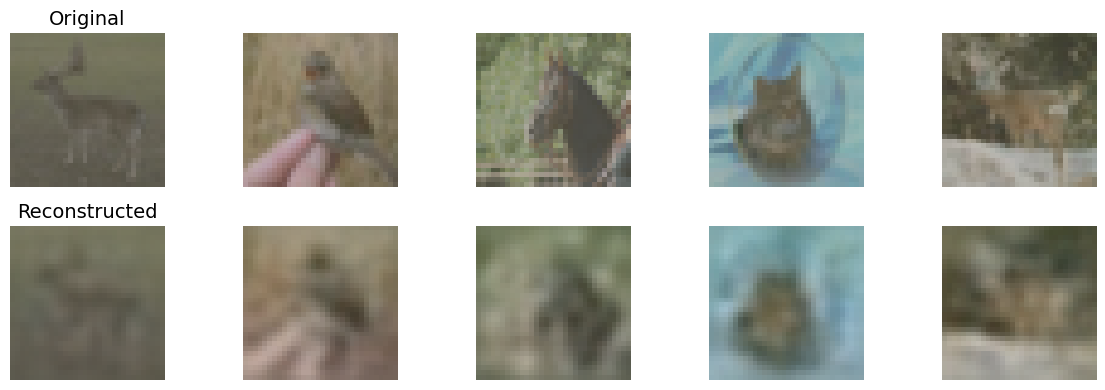

AE Epoch 23: 100%|██████████| 313/313 [00:08<00:00, 36.19it/s]


AE Epoch [23/30] Train Loss: 0.0220, Val Loss: 0.0233


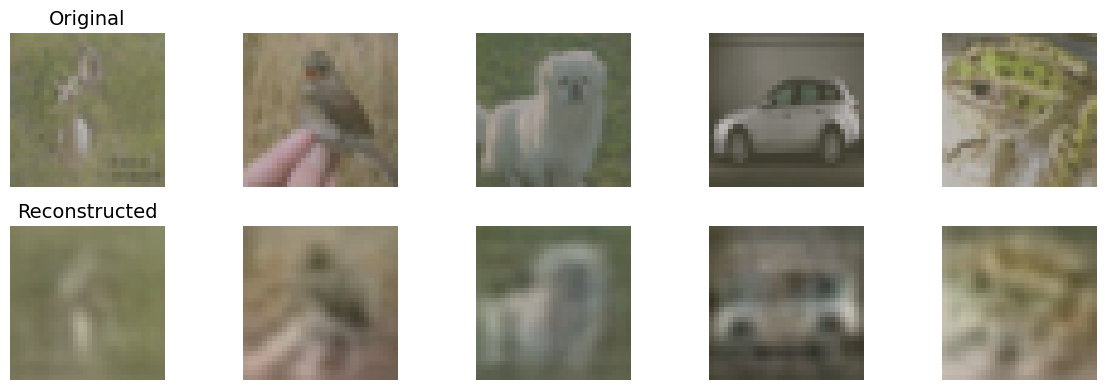

AE Epoch 24: 100%|██████████| 313/313 [00:08<00:00, 36.46it/s]


AE Epoch [24/30] Train Loss: 0.0221, Val Loss: 0.0230


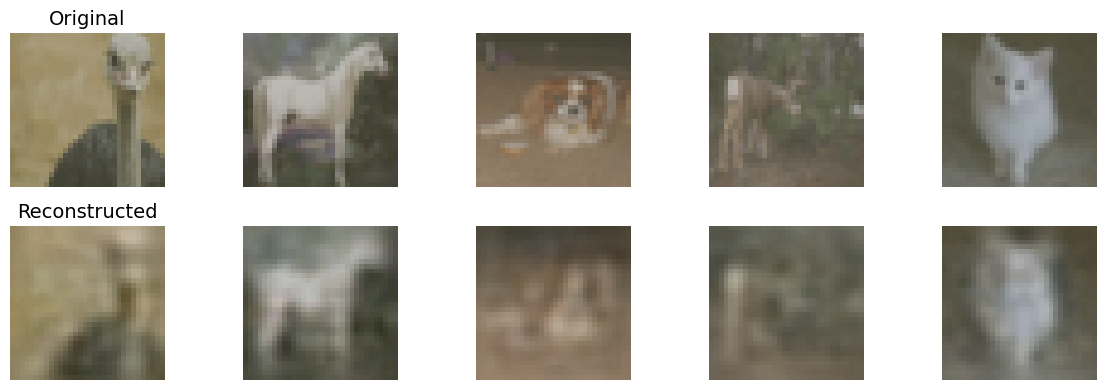

AE Epoch 25: 100%|██████████| 313/313 [00:08<00:00, 35.68it/s]


AE Epoch [25/30] Train Loss: 0.0219, Val Loss: 0.0231


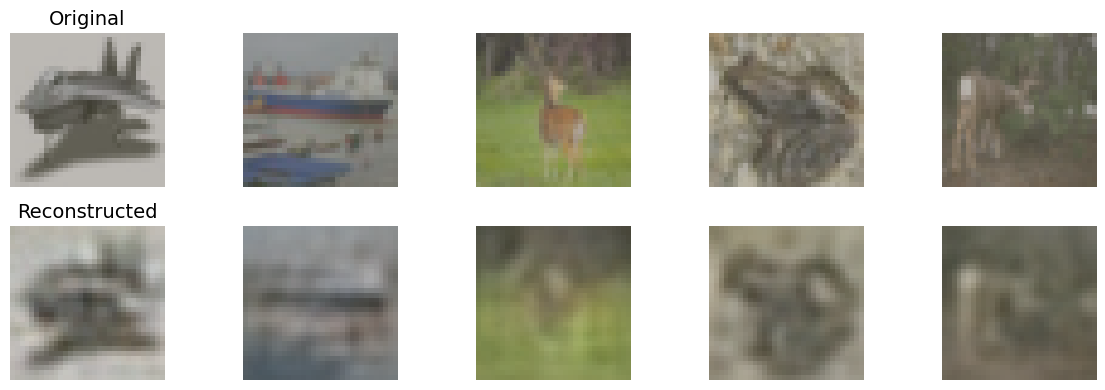

AE Epoch 26: 100%|██████████| 313/313 [00:08<00:00, 35.66it/s]


AE Epoch [26/30] Train Loss: 0.0219, Val Loss: 0.0230


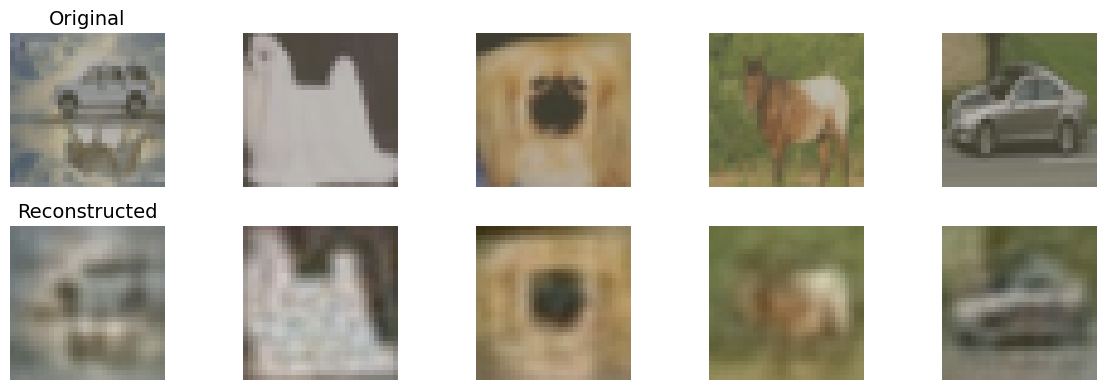

AE Epoch 27: 100%|██████████| 313/313 [00:09<00:00, 34.52it/s]


AE Epoch [27/30] Train Loss: 0.0218, Val Loss: 0.0230


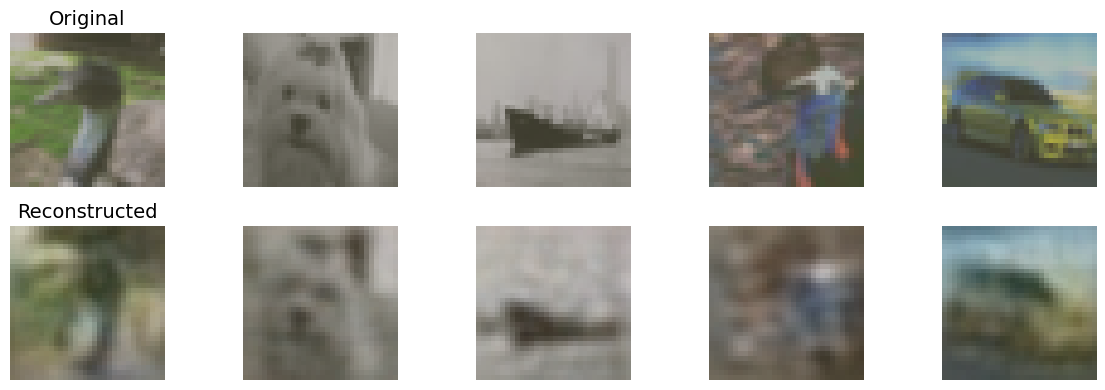

AE Epoch 28: 100%|██████████| 313/313 [00:08<00:00, 35.37it/s]


AE Epoch [28/30] Train Loss: 0.0218, Val Loss: 0.0231


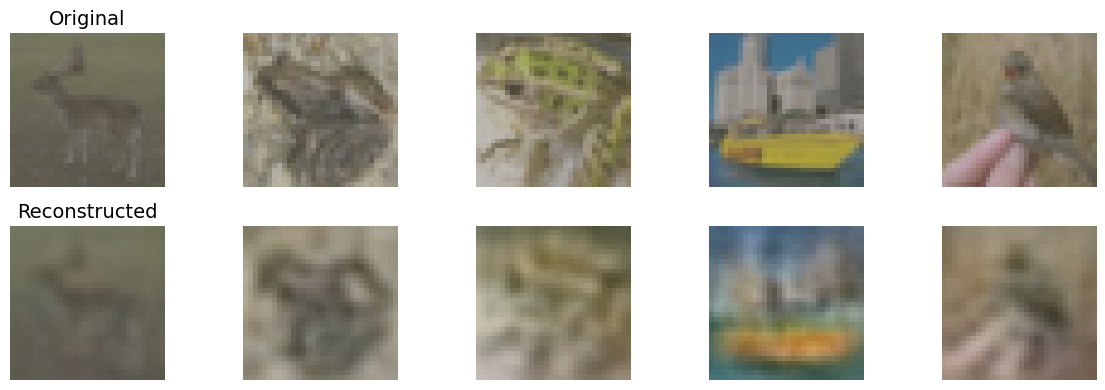

AE Epoch 29: 100%|██████████| 313/313 [00:09<00:00, 34.61it/s]


AE Epoch [29/30] Train Loss: 0.0218, Val Loss: 0.0229


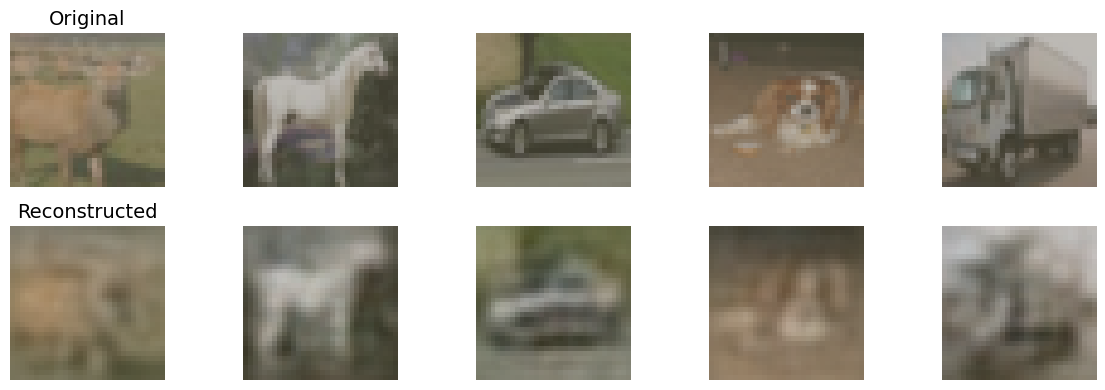

AE Epoch 30: 100%|██████████| 313/313 [00:08<00:00, 34.79it/s]


AE Epoch [30/30] Train Loss: 0.0217, Val Loss: 0.0230


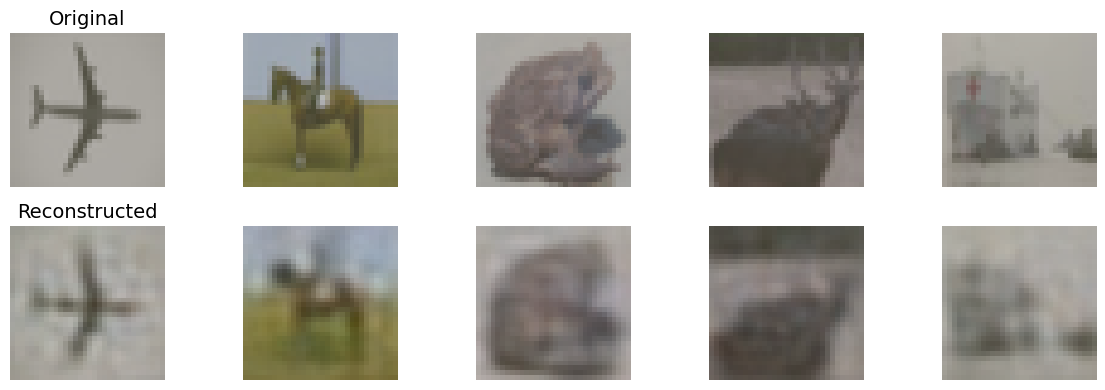

In [9]:
ae = Autoencoder(cfg['input_channels'], cfg['input_size']).to(device)
print(f"Training Autoencoder on {dataset_name}")
ae = train_autoencoder(ae, train_loader, val_loader, device, num_epochs_ae, dataset_name)


In [10]:
ae_test_loss = evaluate(ae, test_loader, device, criterion = nn.MSELoss())
print(f'Test Loss: {ae_test_loss:.4f}')

Test Loss: 0.0230


In [15]:
# Classifier

classifier = Classifier(ae.encoder, ae.input_dim, cfg['num_classes']).to(device)
# classifier = Classifier(ae.encoder, config[dataset_name]['num_classes']).to(device)

for param in classifier.encoder.parameters():
    param.requires_grad = False
print(f"\nTraining Classifier on {dataset_name}")
classifier = train_classifier(classifier, train_loader, val_loader, device, num_epochs_cls, dataset_name)


Training Classifier on CIFAR10


CLS Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]


AttributeError: 'Classifier' object has no attribute 'dropout'

In [15]:

# Final test
test_acc = evaluate_classifier(classifier, test_loader, device)
print(f'\nFinal Test Accuracy on {dataset_name}: {test_acc:.2f}%')



Final Test Accuracy on CIFAR10: 57.76%


In [ ]:
# Visualization
plot_tsne(ae.encoder, test_loader, device)

In [ ]:
###############################################